# Costruzione dell'Indice di Deprivazione Italiano (IDI)

## Applicazione al progetto *EV Charge Desert*

Questo notebook costruisce, controlla ed esporta un **Indice di Deprivazione Italiano ridotto** a livello di sezione di censimento 2011. L'indice viene poi trasformato in un moltiplicatore limitato, utilizzabile in futuro per ripartire le auto elettriche note a livello provinciale.

Il notebook è pensato per essere:

- eseguibile direttamente in **Visual Studio Code** con un kernel Python;
- riproducibile e verificabile in ogni passaggio;
- prudente con le sezioni poco popolate e con i denominatori nulli;
- coerente con la metodologia descritta nei documenti del progetto;
- utilizzabile anche con un file nazionale completo, senza modificare le formule.

### Dipendenze

Sono utilizzati soltanto `pandas`, `numpy`, `matplotlib` e i componenti standard di Python.

### Fonti metodologiche del progetto

- `Indice_Deprivazione_Umanizzato.docx`;
- `Documentazione_Completa_Progetto_EV_Charge_Desert.docx`;
- `EV_Charge_Desert_Quadro_completo.pdf`.

> **Nota importante:** l'IDI è una proxy di posizione socioeconomica e non una stima puntuale del reddito. Nel progetto deve modificare una base demografica, non sostituirla.

## 1. Metodologia

L'IDI originale utilizza cinque dimensioni. Nel file pubblico del Censimento 2011 non è disponibile la componente relativa alle famiglie monogenitoriali; viene quindi calcolata una versione ridotta a quattro componenti:

| Componente | Formula | Interpretazione |
|---|---|---|
| Bassa istruzione | $(P49 + P50) / P46$ | Quota della popolazione di almeno 6 anni con licenza media inferiore o elementare |
| Disoccupazione | $P62 / P60$ | Quota delle forze di lavoro disoccupata |
| Non proprietà | $A46 / PF1$ | Quota delle famiglie residenti in affitto; è una proxy, non comprende ogni altra forma di non proprietà |
| Affollamento | $PF2 / A44$ | Componenti delle famiglie per metro quadrato delle abitazioni occupate |

Per rendere confrontabili le componenti si utilizza lo **z-score robusto**:

$$
z_{ik}=\frac{x_{ik}-\operatorname{mediana}(x_k)}{IQR(x_k)}
$$

dove $IQR=Q_{75}-Q_{25}$. L'indice a quattro componenti è:

$$
IDI_{4,i}=z_{istruzione,i}+z_{disoccupazione,i}+z_{affitto,i}+z_{affollamento,i}
$$

Valori alti indicano maggiore deprivazione. Viene calcolata anche una variante di sensibilità senza la componente affitto:

$$
IDI_{3,i}=z_{istruzione,i}+z_{disoccupazione,i}+z_{affollamento,i}
$$

La variante a tre componenti recepisce il controllo suggerito dal Docente, perché la quota di famiglie in affitto ha mostrato un segno controintuitivo rispetto al reddito comunale.

### Regole di validità

Una sezione riceve un IDI diretto soltanto se:

- è abitata: `P1 > 0`;
- `P46 > 0`, `P60 > 0`, `PF1 > 0` e `A44 > 0`;
- i numeratori delle componenti sono non negativi.

Le sezioni speciali con dati validi restano nel calcolo descrittivo dell'IDI per riprodurre l'universo censuario, ma vengono escluse dall'allocazione spaziale delle EV. Le sezioni abitate ma senza un IDI calcolabile **non vengono cancellate**: in preparazione della ripartizione EV ricevono un moltiplicatore neutrale pari a 1.

## 2. Coerenza con la futura ripartizione delle auto elettriche

La popolazione costituisce l'**esposizione** o dimensione della domanda potenziale; l'IDI modifica soltanto la propensione relativa:

$$
w_i=N_i\times m_i^*
$$

dove:

- $N_i$ è preferibilmente la popolazione stimata in età di guida; in sua assenza si utilizza `P1`;
- $m_i^*$ è il moltiplicatore IDI attenuato;
- $w_i$ sarà il peso utilizzato per ripartire il totale provinciale.

Il rango di benessere viene trasformato in un moltiplicatore limitato tra 0,5 e 1,5. Per non attribuire eccessiva importanza a tassi calcolati su pochissime persone, la soglia di 50 residenti è utilizzata come soglia di **affidabilità**, non come filtro di esclusione:

$$
\lambda_i=\min\left(1,\frac{P1_i}{50}\right)
$$

$$
m_i^*=1+\lambda_i(m_i-1)
$$

Una sezione con due residenti rimane quindi nell'analisi, ma il suo IDI ha un'influenza quasi nulla. In fase di allocazione dovrà inoltre valere:

$$
0\leq\widehat{EV}_i\leq C_i, \qquad
\sum_{i\in p}\widehat{EV}_i=EV_p
$$

Nel notebook viene preparata come capacità prudenziale la popolazione stimata in età di guida. La funzione finale di allocazione applica il limite e conserva esattamente il totale provinciale.

In [1]:
# 3. Parametri modificabili
from pathlib import Path

# Il primo nome e' quello versionato in data/; il secondo e' la copia allegata
# usata durante lo sviluppo.
CSV_FILENAME = [
    "0_sezioni_censimento_2011_ridotto.csv",
    "sezioni_censimento_2011_ridotto(1).csv",
]
CSV_SEPARATOR = ","

# Variante usata per costruire il moltiplicatore EV: "IDI4" oppure "IDI3".
IDI_VARIANT_FOR_EV = "IDI4"

# Soglia di affidabilità: sotto 50 residenti l'effetto dell'IDI viene attenuato.
MIN_POP_FULL_IDI = 50

# Winsorizing bilaterale. Impostare WINSOR_LOWER_Q = 0 per tagliare solo la coda superiore.
WINSOR_LOWER_Q = 0.001
WINSOR_UPPER_Q = 0.999

# Intervallo del moltiplicatore pieno derivato dal rango di benessere.
IDI_MULTIPLIER_MIN = 0.5
IDI_MULTIPLIER_MAX = 1.5

# Per un uso nazionale in produzione impostare True: il notebook si fermerà se mancano regioni.
REQUIRE_ALL_20_REGIONS = False

# Esportazione. Il CSV compresso è sempre prodotto; quello non compresso è facoltativo.
EXPORT_PLAIN_CSV = False
OUTPUT_DIR = (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()) / "output" / "idi"


In [2]:
# 4. Librerie e funzioni di supporto
import csv
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def resolve_csv_path(filename) -> Path:
    nomi = [filename] if isinstance(filename, str) else list(filename)
    cwd = Path.cwd()
    # Radice del repository: il notebook gira da notebooks/, l'input versionato
    # sta in data/ e gli output rigenerati in output/.
    repo = cwd.parent if cwd.name == "notebooks" else cwd
    directories = [repo / "output", repo / "data", cwd, cwd / "upload",
                   cwd.parent / "upload", cwd.parent.parent / "upload"]
    for nome in nomi:
        for directory in directories:
            candidate = directory / nome
            if candidate.exists():
                return candidate.resolve()
    raise FileNotFoundError(
        f"CSV non trovato ({', '.join(nomi)}). Su un clone del repository e'\n"
        "  data/0_sezioni_censimento_2011_ridotto.csv: se e' di ~130 byte manca\n"
        "  `git lfs pull`. Altrimenti aggiornare CSV_FILENAME."
    )

def normalize_code(series: pd.Series, width: int) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(width)
    )

def robust_parameters(series: pd.Series) -> tuple[float, float]:
    clean = series.dropna()
    median = float(clean.median())
    iqr = float(clean.quantile(0.75) - clean.quantile(0.25))
    if not np.isfinite(iqr) or iqr <= 0:
        raise ValueError("IQR nullo o non valido: impossibile standardizzare la componente.")
    return median, iqr

def winsorize_series(series: pd.Series, lower_q: float, upper_q: float):
    clean = series.dropna()
    lower = float(clean.quantile(lower_q)) if lower_q > 0 else float(clean.min())
    upper = float(clean.quantile(upper_q))
    return series.clip(lower=lower, upper=upper), lower, upper

def make_quintile(percentile_rank: pd.Series) -> pd.Series:
    quintile = np.ceil(percentile_rank * 5).clip(1, 5)
    return pd.Series(quintile, index=percentile_rank.index, dtype="Float64").round().astype("Int64")


In [3]:
# 5. Caricamento e controllo dello schema
csv_path = resolve_csv_path(CSV_FILENAME)
print(f"File utilizzato: {csv_path}")

id_dtypes = {
    "CODREG": "Int64",
    "CODPRO": "Int64",
    "CODCOM": "Int64",
    "PROCOM": "string",
    "SEZ2011": "string",
    "NSEZ": "string",
}

df = pd.read_csv(
    csv_path,
    sep=CSV_SEPARATOR,
    dtype=id_dtypes,
    low_memory=False,
)

required_columns = {
    "CODREG", "REGIONE", "CODPRO", "PROVINCIA", "PROCOM", "COMUNE",
    "SEZ2011", "NSEZ", "P1", "P46", "P49", "P50",
    "P60", "P62", "A44", "PF2", "A46", "PF1",
}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise KeyError(f"Mancano le colonne necessarie: {missing_columns}")

df["PROCOM"] = normalize_code(df["PROCOM"], 6)
df["SEZ2011"] = normalize_code(df["SEZ2011"], 13)
df["NSEZ"] = normalize_code(df["NSEZ"], 7)

if df["SEZ2011"].duplicated().any():
    examples = df.loc[df["SEZ2011"].duplicated(keep=False), "SEZ2011"].head().tolist()
    raise ValueError(f"SEZ2011 non è univoco. Esempi: {examples}")

numeric_columns = ["P1", "P46", "P49", "P50", "P60", "P62", "A44", "PF2", "A46", "PF1"]
if "popolazione_eta_guida_stimata" in df.columns:
    numeric_columns.append("popolazione_eta_guida_stimata")
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Controllo strutturale dell'ultima riga: utile per intercettare file troncati durante un trasferimento.
with csv_path.open("rb") as handle:
    header_line = handle.readline().decode("utf-8-sig")
    header = next(csv.reader([header_line], delimiter=CSV_SEPARATOR))
    handle.seek(0, 2)
    end = handle.tell()
    handle.seek(max(0, end - 16_384))
    tail_text = handle.read().decode("utf-8", errors="replace")
    tail_lines = [line for line in tail_text.splitlines() if line.strip()]
    last_fields = next(csv.reader([tail_lines[-1]], delimiter=CSV_SEPARATOR))
tail_row_complete = len(last_fields) == len(header)

print(f"Righe: {len(df):,}; colonne: {df.shape[1]}")
print(f"SEZ2011 duplicati: {df['SEZ2011'].duplicated().sum():,}")
print(f"Ultima riga strutturalmente completa: {tail_row_complete}")
display(df.head(3))


File utilizzato: /workspace/scratch/35a11f094ce2/upload/sezioni_censimento_2011_ridotto(1).csv
Righe: 366,863; colonne: 47
SEZ2011 duplicati: 0
Ultima riga strutturalmente completa: True
   CODREG   REGIONE  CODPRO PROVINCIA  CODCOM COMUNE  PROCOM        SEZ2011  \
0       1  Piemonte       1    Torino       1  Agliè  001001  0010010000001   
1       1  Piemonte       1    Torino       1  Agliè  001001  0010010000002   
2       1  Piemonte       1    Torino       1  Agliè  001001  0010010000006   

      NSEZ  ACE  CODLOC  CODASC   P1  P46  P49  P50  P60  P62    A44  PF2  \
0  0000001    0   10001     NaN  805  752  240  196  355   31  36936  800   
1  0000002    0   10001     NaN  717  686  199  131  331   15  36789  717   
2  0000006    0   10001     NaN   26   25   10    4   11    2   1156   26   

   A46  PF1   E8  E9  E10  E11  E12  E13  E14  E15  E16  E17  E18  E19  E20  \
0  113  419  271   5   14   20    1    0    2    0    0   20  169  107   17   
1   59  329   14  16   22   4

In [4]:
# 6. Controllo della copertura geografica
observed_regions = set(pd.to_numeric(df["CODREG"], errors="coerce").dropna().astype(int).unique())
expected_regions = set(range(1, 21))
missing_regions = sorted(expected_regions - observed_regions)
extra_regions = sorted(observed_regions - expected_regions)
coverage_complete = not missing_regions and not extra_regions and tail_row_complete

coverage_table = (
    df.groupby(["CODREG", "REGIONE"], dropna=False)
    .size()
    .rename("numero_sezioni")
    .reset_index()
    .sort_values("CODREG")
)
display(coverage_table)
print(f"Regioni osservate: {len(observed_regions)} su 20")
print(f"Codici regione mancanti: {missing_regions or 'nessuno'}")

if not coverage_complete:
    message = (
        "Il file non presenta una copertura nazionale completa o la riga finale appare troncata. "
        "L'IDI viene comunque calcolato sulle righe disponibili, ma mediane, IQR, ranghi e quintili "
        "non possono essere definiti nazionali. Prima dell'uso in produzione occorre rieseguire il "
        "notebook sul CSV completo delle 20 regioni."
    )
    if REQUIRE_ALL_20_REGIONS:
        raise ValueError(message)
    warnings.warn(message, RuntimeWarning)

reference_scope = "nazionale" if coverage_complete else f"dataset disponibile ({len(observed_regions)} regioni)"
print(f"Ambito effettivo della standardizzazione: {reference_scope}")


    CODREG                       REGIONE  numero_sezioni
0        1                      Piemonte           31830
1        2  Valle d'Aosta/Vallée d'Aoste            1486
2        3                     Lombardia           48220
3        4  Trentino-Alto Adige/Südtirol           10010
4        5                        Veneto           32058
5        6         Friuli-Venezia Giulia            7243
6        7                       Liguria           10441
7        8                Emilia-Romagna           37013
8        9                       Toscana           27078
9       10                        Umbria            7092
10      11                        Marche           11134
11      12                         Lazio           29123
12      13                       Abruzzo            8280
13      14                        Molise            2357
14      15                      Campania           22178
15      16                        Puglia           20627
16      17                    B

## 7. Costruzione dei flag di qualità

Le sezioni con popolazione nulla restano nel file ma non ricevono né IDI né peso EV. Le sezioni speciali possono ricevere un IDI descrittivo se le componenti sono calcolabili, ma ricevono sempre peso EV pari a zero perché non rappresentano normali aree residenziali localizzabili.

Le sezioni speciali riconosciute tramite `NSEZ` sono:

- `9999999` e `9999998`: zone in contestazione;
- `8888881`–`8888889`: sezioni convenzionali per persone senza dimora;
- `7777777`: sezione speciale legata al sisma dell'Abruzzo del 2009.

La soglia di 50 residenti produce soltanto il flag `flag_bassa_popolazione`; non elimina la sezione.

In [5]:
# 7. Flag di qualità e di calcolabilità
nsez_numeric = pd.to_numeric(df["NSEZ"], errors="coerce")
df["flag_sezione_speciale"] = (
    nsez_numeric.isin([9_999_999, 9_999_998, 7_777_777])
    | nsez_numeric.between(8_888_881, 8_888_889)
)
df["flag_abitata"] = df["P1"].gt(0)
df["flag_bassa_popolazione"] = df["P1"].between(1, MIN_POP_FULL_IDI - 1)

denominators = ["P46", "P60", "PF1", "A44"]
numerators = ["P49", "P50", "P62", "PF2", "A46"]
df["flag_denominatori_idi_validi"] = df[denominators].gt(0).all(axis=1)
df["flag_numeratori_idi_validi"] = df[numerators].ge(0).all(axis=1) & df[numerators].notna().all(axis=1)
df["flag_idi_calcolabile"] = (
    df["flag_abitata"]
    & df["flag_denominatori_idi_validi"]
    & df["flag_numeratori_idi_validi"]
)
df["flag_idi_utilizzabile_EV"] = (
    df["flag_idi_calcolabile"] & ~df["flag_sezione_speciale"]
)

df["motivo_idi_non_calcolabile"] = np.select(
    [
        ~df["flag_abitata"],
        df["P46"].le(0) | df["P46"].isna(),
        df["P60"].le(0) | df["P60"].isna(),
        df["PF1"].le(0) | df["PF1"].isna(),
        df["A44"].le(0) | df["A44"].isna(),
        ~df["flag_numeratori_idi_validi"],
    ],
    [
        "popolazione_zero",
        "P46_non_valido",
        "P60_non_valido",
        "PF1_non_valido",
        "A44_non_valido",
        "numeratore_non_valido",
    ],
    default="",
)

valid_idi = df["flag_idi_calcolabile"]
quality_summary = pd.DataFrame({
    "metrica": [
        "Sezioni totali", "Sezioni abitate", "Sezioni speciali",
        "Sezioni con IDI calcolabile", "Sezioni standard con IDI utilizzabile per EV",
        "Sezioni abitate senza IDI diretto",
        f"Sezioni con 1-{MIN_POP_FULL_IDI - 1} residenti",
    ],
    "valore": [
        len(df), int(df["flag_abitata"].sum()), int(df["flag_sezione_speciale"].sum()),
        int(valid_idi.sum()), int(df["flag_idi_utilizzabile_EV"].sum()),
        int((df["flag_abitata"] & ~valid_idi).sum()),
        int(df["flag_bassa_popolazione"].sum()),
    ],
})
quality_summary["percentuale_sul_totale"] = quality_summary["valore"] / len(df)
quality_summary_display = quality_summary.copy()
quality_summary_display["percentuale_sul_totale"] = quality_summary_display["percentuale_sul_totale"].map(lambda x: f"{x:.2%}")
display(quality_summary_display)
display(df.loc[~valid_idi, "motivo_idi_non_calcolabile"].value_counts(dropna=False).rename_axis("motivo").to_frame("sezioni"))


                                        metrica  valore percentuale_sul_totale
0                                Sezioni totali  366863                100.00%
1                               Sezioni abitate  349033                 95.14%
2                              Sezioni speciali    1107                  0.30%
3                   Sezioni con IDI calcolabile  341354                 93.05%
4  Sezioni standard con IDI utilizzabile per EV  341331                 93.04%
5             Sezioni abitate senza IDI diretto    7679                  2.09%
6                    Sezioni con 1-49 residenti  139183                 37.94%
                  sezioni
motivo                   
popolazione_zero    17830
P60_non_valido       6153
A44_non_valido       1083
PF1_non_valido        437
P46_non_valido          6


## 8. Calcolo delle quattro componenti

Le componenti sono calcolate soltanto sulle sezioni valide. I valori delle altre sezioni restano mancanti (`NaN`), evitando divisioni per zero o sostituzioni arbitrarie.

La componente `affollamento` usa `A44`, cioè la superficie interna complessiva delle abitazioni occupate. **Non è l'area geografica della sezione censuaria.**

In [6]:
# 8. Componenti grezze dell'IDI
df["comp_bassa_istruzione"] = np.where(
    valid_idi, (df["P49"] + df["P50"]) / df["P46"], np.nan
)
df["comp_disoccupazione"] = np.where(valid_idi, df["P62"] / df["P60"], np.nan)
df["comp_non_proprieta"] = np.where(valid_idi, df["A46"] / df["PF1"], np.nan)
df["comp_affollamento"] = np.where(valid_idi, df["PF2"] / df["A44"], np.nan)

component_columns = [
    "comp_bassa_istruzione",
    "comp_disoccupazione",
    "comp_non_proprieta",
    "comp_affollamento",
]

component_summary = df.loc[valid_idi, component_columns].describe(
    percentiles=[0.001, 0.01, 0.25, 0.5, 0.75, 0.99, 0.999]
).T
display(component_summary)
display(df.loc[valid_idi, component_columns].corr(method="spearman").round(3))


                             count   mean    std    min   0.1%     1%    25%  \
comp_bassa_istruzione 341,354.0000 0.4988 0.1613 0.0000 0.0000 0.0000 0.4071   
comp_disoccupazione   341,354.0000 0.0715 0.0869 0.0000 0.0000 0.0000 0.0000   
comp_non_proprieta    341,354.0000 0.1564 0.1787 0.0000 0.0000 0.0000 0.0208   
comp_affollamento     341,354.0000 0.0247 0.0115 0.0011 0.0057 0.0105 0.0205   

                         50%    75%    99%  99.9%    max  
comp_bassa_istruzione 0.5079 0.5957 1.0000 1.0000 1.0000  
comp_disoccupazione   0.0554 0.1000 0.3750 1.0000 1.0000  
comp_non_proprieta    0.1111 0.2215 0.9270 1.0000 1.0000  
comp_affollamento     0.0240 0.0277 0.0476 0.0836 2.5789  
                       comp_bassa_istruzione  comp_disoccupazione  \
comp_bassa_istruzione                 1.0000               0.0630   
comp_disoccupazione                   0.0630               1.0000   
comp_non_proprieta                   -0.0730               0.2210   
comp_affollamento           

## 9. Standardizzazione robusta e costruzione dell'IDI

Mediane e IQR devono essere calcolati sullo stesso universo territoriale che si vuole confrontare. Per l'uso nazionale servono tutte le 20 regioni nello stesso file. Se la copertura è incompleta, il notebook continua per consentire lo sviluppo e il controllo della pipeline, ma etichetta esplicitamente il riferimento come parziale.

Dopo la somma degli z-score si applica il winsorizing configurato nei parametri. I valori grezzi restano disponibili per audit.

In [7]:
# 9. Z-score robusti
z_columns = []
benchmark_rows = []

for component in component_columns:
    median, iqr = robust_parameters(df.loc[valid_idi, component])
    z_column = component.replace("comp_", "z_")
    df[z_column] = np.where(valid_idi, (df[component] - median) / iqr, np.nan)
    z_columns.append(z_column)
    benchmark_rows.append({
        "componente": component,
        "mediana": median,
        "IQR": iqr,
        "ambito": reference_scope,
    })

benchmark_table = pd.DataFrame(benchmark_rows)
display(benchmark_table)

df["IDI4_grezzo"] = df[z_columns].sum(axis=1, min_count=4)
z_without_rent = [column for column in z_columns if column != "z_non_proprieta"]
df["IDI3_grezzo"] = df[z_without_rent].sum(axis=1, min_count=3)

df["IDI4_winsor"], idi4_lower, idi4_upper = winsorize_series(
    df["IDI4_grezzo"], WINSOR_LOWER_Q, WINSOR_UPPER_Q
)
df["IDI3_winsor"], idi3_lower, idi3_upper = winsorize_series(
    df["IDI3_grezzo"], WINSOR_LOWER_Q, WINSOR_UPPER_Q
)

winsor_table = pd.DataFrame([
    {"indice": "IDI4", "limite_inferiore": idi4_lower, "limite_superiore": idi4_upper},
    {"indice": "IDI3", "limite_inferiore": idi3_lower, "limite_superiore": idi3_upper},
])
display(winsor_table)
display(df.loc[valid_idi, ["IDI4_grezzo", "IDI4_winsor", "IDI3_grezzo", "IDI3_winsor"]].describe(
    percentiles=[0.001, 0.01, 0.25, 0.5, 0.75, 0.99, 0.999]
).T)


              componente  mediana    IQR     ambito
0  comp_bassa_istruzione   0.5079 0.1887  nazionale
1    comp_disoccupazione   0.0554 0.1000  nazionale
2     comp_non_proprieta   0.1111 0.2007  nazionale
3      comp_affollamento   0.0240 0.0072  nazionale
  indice  limite_inferiore  limite_superiore
0   IDI4           -6.0704           13.2034
1   IDI3           -5.5840           12.0142
                   count   mean    std     min    0.1%      1%     25%    50%  \
IDI4_grezzo 341,354.0000 0.4394 2.4670 -6.9761 -6.0704 -4.1351 -0.7981 0.2101   
IDI4_winsor 341,354.0000 0.4290 2.1225 -6.0704 -6.0691 -4.1351 -0.7981 0.2101   
IDI3_grezzo 341,354.0000 0.2138 2.1857 -6.4224 -5.5840 -3.8755 -0.7951 0.1119   
IDI3_winsor 341,354.0000 0.2034 1.7874 -5.5840 -5.5840 -3.8755 -0.7951 0.1119   

               75%    99%   99.9%      max  
IDI4_grezzo 1.3572 7.4347 13.2034 356.3542  
IDI4_winsor 1.3572 7.4347 13.1943  13.2034  
IDI3_grezzo 1.0514 5.6720 12.0142 356.9080  
IDI3_winsor 1.0514 

In [8]:
# 10. Ranghi e quintili di deprivazione
for variant in ["IDI4", "IDI3"]:
    index_column = f"{variant}_winsor"
    percentile_column = f"percentile_deprivazione_{variant}"
    quintile_column = f"quintile_deprivazione_{variant}"
    df[percentile_column] = df[index_column].rank(method="average", pct=True)
    df[quintile_column] = make_quintile(df[percentile_column])

selected_idi_column = f"{IDI_VARIANT_FOR_EV}_winsor"
selected_percentile_column = f"percentile_deprivazione_{IDI_VARIANT_FOR_EV}"
selected_quintile_column = f"quintile_deprivazione_{IDI_VARIANT_FOR_EV}"

df["IDI_selezionato_per_EV"] = df[selected_idi_column]
df["percentile_deprivazione_selezionato"] = df[selected_percentile_column]
df["quintile_deprivazione_selezionato"] = df[selected_quintile_column]
df["affluenza_IDI"] = -df["IDI_selezionato_per_EV"]
df["percentile_benessere"] = 1 - df["percentile_deprivazione_selezionato"]

print(f"Variante selezionata per la preparazione EV: {IDI_VARIANT_FOR_EV}")
print(f"Riferimento di ranghi e quintili: {reference_scope}")
display(
    df.loc[valid_idi, selected_quintile_column]
    .value_counts()
    .sort_index()
    .rename_axis("quintile_deprivazione")
    .to_frame("numero_sezioni")
)


Variante selezionata per la preparazione EV: IDI4
Riferimento di ranghi e quintili: nazionale
                       numero_sezioni
quintile_deprivazione                
1                               68270
2                               68271
3                               68271
4                               68271
5                               68271


## 11. Moltiplicatore IDI attenuato e peso per la ripartizione EV

Il rango di benessere è trasformato linearmente nell'intervallo configurato. Il valore è poi riportato verso 1 per le sezioni con meno di 50 residenti.

Le sezioni senza IDI diretto ricevono un moltiplicatore neutrale pari a 1. Non vengono quindi favorite né penalizzate dall'indicatore mancante.

Come esposizione viene usata `popolazione_eta_guida_stimata`, se presente. Questa variabile **non è una componente dell'IDI**: serve soltanto a rendere plausibile la futura ripartizione delle auto. Se la colonna non è disponibile, il notebook utilizza `P1`.

In [9]:
# 11. Moltiplicatore pieno, attenuazione e peso EV
df["moltiplicatore_IDI_pieno"] = (
    IDI_MULTIPLIER_MIN
    + (IDI_MULTIPLIER_MAX - IDI_MULTIPLIER_MIN) * df["percentile_benessere"]
)
df.loc[~valid_idi, "moltiplicatore_IDI_pieno"] = 1.0

df["lambda_affidabilita_IDI"] = (df["P1"] / MIN_POP_FULL_IDI).clip(lower=0, upper=1)
df.loc[~valid_idi, "lambda_affidabilita_IDI"] = 0.0
df["moltiplicatore_IDI_attenuato"] = (
    1 + df["lambda_affidabilita_IDI"] * (df["moltiplicatore_IDI_pieno"] - 1)
)

if "popolazione_eta_guida_stimata" in df.columns:
    exposure_column = "popolazione_eta_guida_stimata"
else:
    exposure_column = "P1"
    warnings.warn("Manca popolazione_eta_guida_stimata: viene utilizzata P1 come esposizione EV.")

df["esposizione_EV"] = pd.to_numeric(df[exposure_column], errors="coerce")
df["flag_esposizione_EV_valida"] = (
    df["flag_abitata"]
    & ~df["flag_sezione_speciale"]
    & df["esposizione_EV"].gt(0)
    & df["esposizione_EV"].le(df["P1"])
)
df["peso_ripartizione_EV"] = np.where(
    df["flag_esposizione_EV_valida"],
    df["esposizione_EV"] * df["moltiplicatore_IDI_attenuato"],
    0.0,
)
df["capacita_massima_EV_residenziali"] = np.where(
    df["flag_esposizione_EV_valida"],
    np.floor(df["esposizione_EV"]),
    0,
).astype("int64")

allocation_preparation_summary = pd.DataFrame({
    "metrica": [
        "Colonna di esposizione",
        "Sezioni con esposizione EV valida",
        "Sezioni senza IDI ma con peso demografico neutrale",
        "Moltiplicatore attenuato minimo",
        "Moltiplicatore attenuato massimo",
    ],
    "valore": [
        exposure_column,
        int(df["flag_esposizione_EV_valida"].sum()),
        int((df["flag_esposizione_EV_valida"] & ~valid_idi).sum()),
        float(df.loc[df["flag_esposizione_EV_valida"], "moltiplicatore_IDI_attenuato"].min()),
        float(df.loc[df["flag_esposizione_EV_valida"], "moltiplicatore_IDI_attenuato"].max()),
    ],
})
display(allocation_preparation_summary)
display(df.loc[df["P1"].between(1, 5), [
    "SEZ2011", "P1", "esposizione_EV", "IDI_selezionato_per_EV",
    "lambda_affidabilita_IDI", "moltiplicatore_IDI_pieno",
    "moltiplicatore_IDI_attenuato", "peso_ripartizione_EV",
]].head(10))


                                             metrica  \
0                             Colonna di esposizione   
1                  Sezioni con esposizione EV valida   
2  Sezioni senza IDI ma con peso demografico neut...   
3                    Moltiplicatore attenuato minimo   
4                   Moltiplicatore attenuato massimo   

                          valore  
0  popolazione_eta_guida_stimata  
1                         346509  
2                           5260  
3                         0.5005  
4                         1.4952  
           SEZ2011  P1  esposizione_EV  IDI_selezionato_per_EV  \
33   0010020000011   1               0                     NaN   
43   0010028888888   4               3                     NaN   
51   0010030000018   5               5                  1.8270   
54   0010030000023   1               1                 -5.9426   
130  0010080000040   4               2                  1.2538   
137  0010080000051   4               4                 -1

In [10]:
# 12. Controlli di sensibilità tra IDI4 e IDI3
sensitivity = pd.DataFrame({
    "metrica": [
        "Correlazione Spearman IDI4-IDI3",
        "Sezioni che cambiano quintile",
        "Percentuale sezioni che cambiano quintile",
    ],
    "valore": [
        df.loc[valid_idi, "IDI4_winsor"].corr(df.loc[valid_idi, "IDI3_winsor"], method="spearman"),
        int((df.loc[valid_idi, "quintile_deprivazione_IDI4"] != df.loc[valid_idi, "quintile_deprivazione_IDI3"]).sum()),
        float((df.loc[valid_idi, "quintile_deprivazione_IDI4"] != df.loc[valid_idi, "quintile_deprivazione_IDI3"]).mean()),
    ],
})
display(sensitivity)

regional_quality = (
    df.groupby(["CODREG", "REGIONE"], dropna=False)
    .agg(
        sezioni=("SEZ2011", "size"),
        popolazione=("P1", "sum"),
        sezioni_abitate=("flag_abitata", "sum"),
        sezioni_idi_valido=("flag_idi_calcolabile", "sum"),
        sezioni_idi_utilizzabile_ev=("flag_idi_utilizzabile_EV", "sum"),
        sezioni_bassa_popolazione=("flag_bassa_popolazione", "sum"),
        sezioni_esposizione_ev_valida=("flag_esposizione_EV_valida", "sum"),
    )
    .reset_index()
    .sort_values("CODREG")
)
regional_quality["copertura_idi_su_abitate"] = (
    regional_quality["sezioni_idi_valido"] / regional_quality["sezioni_abitate"].replace(0, np.nan)
)
regional_quality_display = regional_quality.copy()
regional_quality_display["copertura_idi_su_abitate"] = regional_quality_display["copertura_idi_su_abitate"].map(lambda x: f"{x:.2%}")
display(regional_quality_display)


                                     metrica       valore
0            Correlazione Spearman IDI4-IDI3       0.9031
1              Sezioni che cambiano quintile 132,417.0000
2  Percentuale sezioni che cambiano quintile       0.3879
    CODREG                       REGIONE  sezioni  popolazione  \
0        1                      Piemonte    31830      4363916   
1        2  Valle d'Aosta/Vallée d'Aoste     1486       126806   
2        3                     Lombardia    48220      9704151   
3        4  Trentino-Alto Adige/Südtirol    10010      1029475   
4        5                        Veneto    32058      4857210   
5        6         Friuli-Venezia Giulia     7243      1218985   
6        7                       Liguria    10441      1570694   
7        8                Emilia-Romagna    37013      4342135   
8        9                       Toscana    27078      3672202   
9       10                        Umbria     7092       884268   
10      11                        Marche  

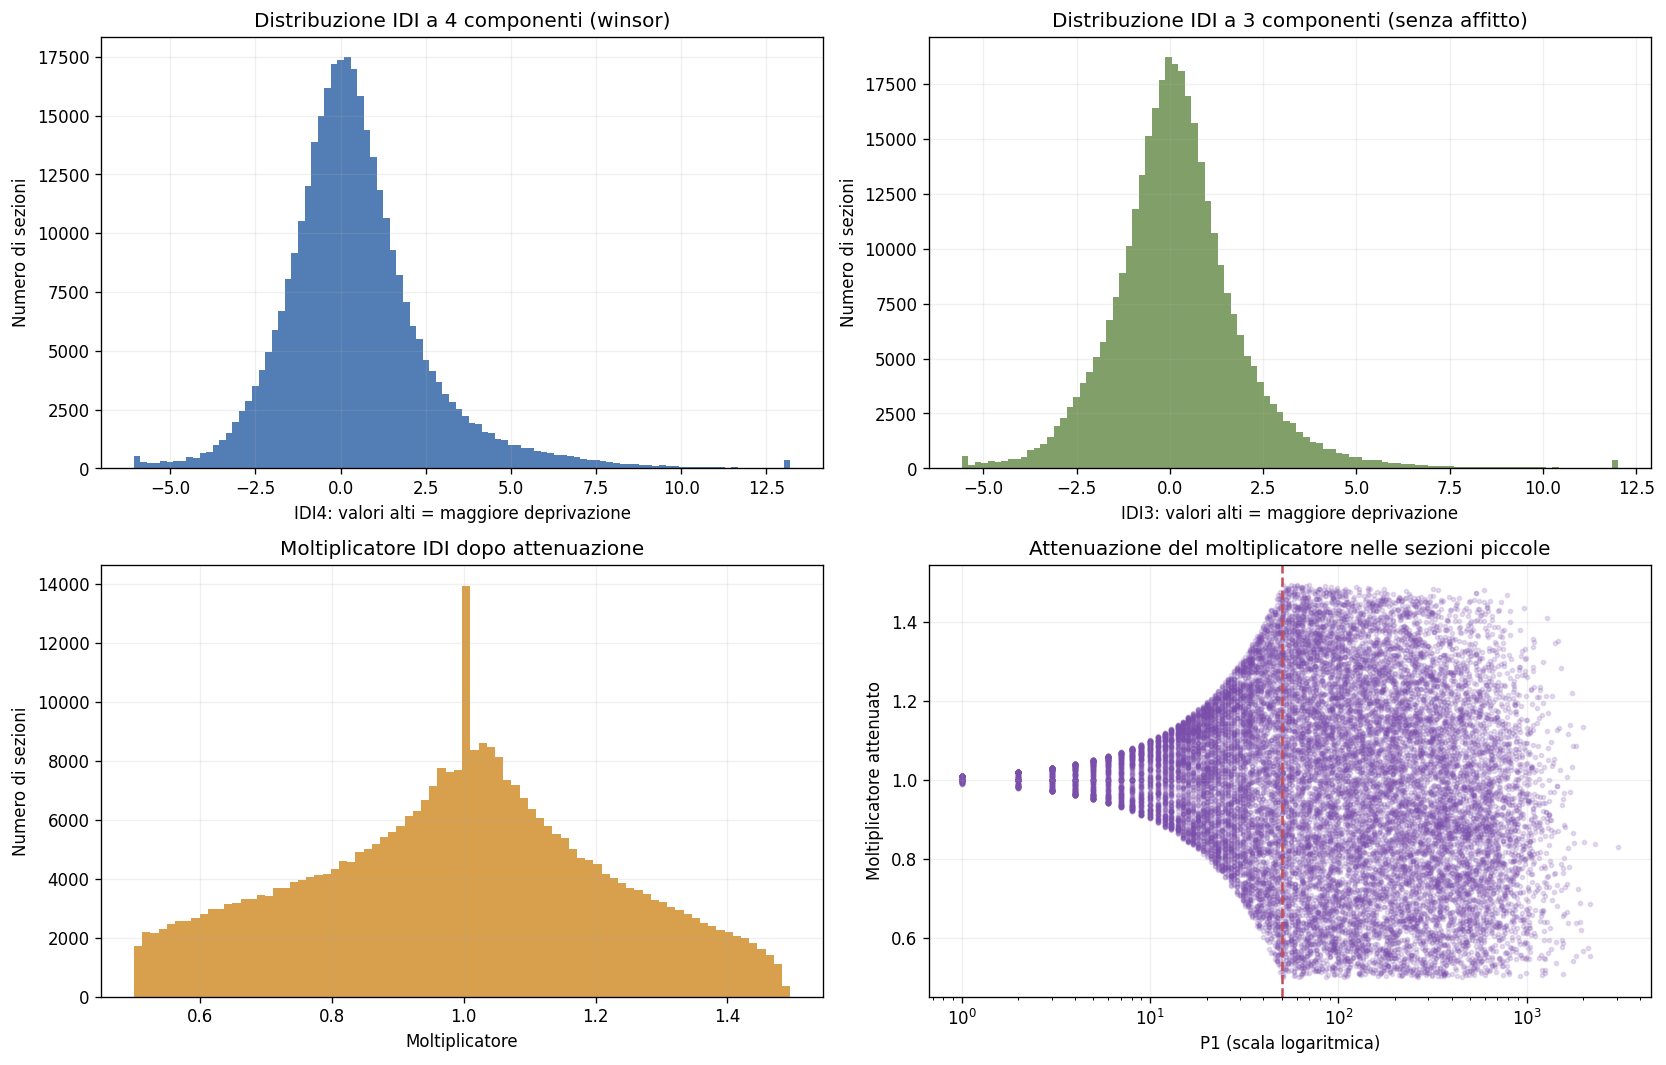

In [11]:
# 13. Visualizzazioni diagnostiche
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(df.loc[valid_idi, "IDI4_winsor"], bins=100, color="#3567A8", alpha=0.85)
axes[0, 0].set_title("Distribuzione IDI a 4 componenti (winsor)")
axes[0, 0].set_xlabel("IDI4: valori alti = maggiore deprivazione")
axes[0, 0].set_ylabel("Numero di sezioni")

axes[0, 1].hist(df.loc[valid_idi, "IDI3_winsor"], bins=100, color="#6B8E4E", alpha=0.85)
axes[0, 1].set_title("Distribuzione IDI a 3 componenti (senza affitto)")
axes[0, 1].set_xlabel("IDI3: valori alti = maggiore deprivazione")
axes[0, 1].set_ylabel("Numero di sezioni")

axes[1, 0].hist(
    df.loc[df["flag_esposizione_EV_valida"], "moltiplicatore_IDI_attenuato"],
    bins=80, color="#D28E2C", alpha=0.85
)
axes[1, 0].set_title("Moltiplicatore IDI dopo attenuazione")
axes[1, 0].set_xlabel("Moltiplicatore")
axes[1, 0].set_ylabel("Numero di sezioni")

sample = df.loc[df["flag_esposizione_EV_valida"]].sample(
    n=min(20_000, int(df["flag_esposizione_EV_valida"].sum())),
    random_state=42,
)
axes[1, 1].scatter(
    sample["P1"], sample["moltiplicatore_IDI_attenuato"],
    s=6, alpha=0.18, color="#7A4EAB"
)
axes[1, 1].set_xscale("log")
axes[1, 1].axvline(MIN_POP_FULL_IDI, color="#C44E52", linestyle="--", linewidth=1.5)
axes[1, 1].set_title("Attenuazione del moltiplicatore nelle sezioni piccole")
axes[1, 1].set_xlabel("P1 (scala logaritmica)")
axes[1, 1].set_ylabel("Moltiplicatore attenuato")

for ax in axes.flat:
    ax.grid(alpha=0.18)
fig.tight_layout()
plt.show()


## 14. Funzione opzionale per la futura allocazione provinciale

La funzione seguente non viene applicata ai dati reali perché il file con il totale EV per provincia non è tra gli input di questo notebook. È già pronta per la fase successiva.

L'algoritmo:

1. ripartisce il totale proporzionalmente a `peso_ripartizione_EV`;
2. applica `capacita_massima_EV_residenziali`;
3. redistribuisce l'eventuale eccedenza;
4. trasforma le stime in numeri interi con il metodo dei resti maggiori;
5. verifica che la somma finale coincida esattamente con il totale provinciale.

> Il vincolo demografico è adatto alla componente residenziale. Auto aziendali e flotte dovrebbero essere separate o trattate con un modello specifico.

In [12]:
# 14. Allocazione intera con limiti di capacità
def allocate_integer_with_caps(weights, capacities, total):
    weights = pd.Series(weights, dtype="float64").fillna(0).clip(lower=0)
    capacities = pd.Series(capacities, index=weights.index, dtype="float64").fillna(0).clip(lower=0)
    capacities = np.floor(capacities).astype("int64")
    total = int(total)

    if total < 0:
        raise ValueError("Il totale EV non può essere negativo.")
    if total > int(capacities.sum()):
        raise ValueError(
            f"Totale EV ({total:,}) superiore alla capacità residenziale ({int(capacities.sum()):,}). "
            "Verificare il dato, il cap o la presenza di flotte aziendali."
        )

    continuous = pd.Series(0.0, index=weights.index)
    active = capacities.gt(0)
    remaining = float(total)

    while remaining > 1e-9:
        active_index = active[active].index
        if len(active_index) == 0:
            raise RuntimeError("Capacità esaurita prima di allocare il totale.")
        remaining_capacity = capacities.loc[active_index] - continuous.loc[active_index]
        active_weights = weights.loc[active_index]
        if active_weights.sum() <= 0:
            active_weights = remaining_capacity.astype(float)
        proposal = remaining * active_weights / active_weights.sum()
        capped = proposal.ge(remaining_capacity - 1e-12)
        if capped.any():
            capped_index = capped[capped].index
            addition = remaining_capacity.loc[capped_index]
            continuous.loc[capped_index] += addition
            remaining -= float(addition.sum())
            active.loc[capped_index] = False
        else:
            continuous.loc[active_index] += proposal
            remaining = 0.0

    integer_allocation = np.floor(continuous + 1e-12).astype("int64")
    residual = total - int(integer_allocation.sum())
    if residual > 0:
        fractions = (continuous - integer_allocation).where(integer_allocation.lt(capacities), -np.inf)
        recipients = fractions.sort_values(ascending=False).head(residual).index
        integer_allocation.loc[recipients] += 1

    if int(integer_allocation.sum()) != total:
        raise AssertionError("La somma allocata non coincide con il totale richiesto.")
    if integer_allocation.gt(capacities).any():
        raise AssertionError("Almeno una sezione supera la capacità.")
    return integer_allocation

# Dimostrazione: una sezione con due residenti non può ricevere dieci auto.
demo = pd.DataFrame({
    "sezione": ["piccola", "media", "grande"],
    "peso": [2.02, 110.0, 180.0],
    "capacita": [2, 100, 200],
}).set_index("sezione")
demo["EV_allocate"] = allocate_integer_with_caps(demo["peso"], demo["capacita"], total=30)
display(demo)


            peso  capacita  EV_allocate
sezione                                
piccola   2.0200         2            0
media   110.0000       100           11
grande  180.0000       200           19


## 15. Esportazione e tracciabilità

Il notebook esporta:

- un CSV compresso con variabili originali, componenti, z-score, IDI, flag e peso EV;
- una tabella sintetica della qualità per regione;
- un file JSON con parametri, mediane, IQR e limiti di winsorizing.

Il file completo di origine non viene modificato.

In [13]:
# 15. Esportazione
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_columns = [
    "CODREG", "REGIONE", "CODPRO", "PROVINCIA", "CODCOM", "COMUNE",
    "PROCOM", "SEZ2011", "NSEZ",
    "P1", "P46", "P49", "P50", "P60", "P62", "A44", "PF2", "A46", "PF1",
]
if "popolazione_eta_guida_stimata" in df.columns:
    output_columns.append("popolazione_eta_guida_stimata")
output_columns += [
    "flag_abitata", "flag_sezione_speciale", "flag_bassa_popolazione",
    "flag_denominatori_idi_validi", "flag_numeratori_idi_validi",
    "flag_idi_calcolabile", "flag_idi_utilizzabile_EV", "motivo_idi_non_calcolabile",
    *component_columns, *z_columns,
    "IDI4_grezzo", "IDI4_winsor", "IDI3_grezzo", "IDI3_winsor",
    "percentile_deprivazione_IDI4", "quintile_deprivazione_IDI4",
    "percentile_deprivazione_IDI3", "quintile_deprivazione_IDI3",
    "IDI_selezionato_per_EV", "percentile_deprivazione_selezionato",
    "quintile_deprivazione_selezionato", "affluenza_IDI", "percentile_benessere",
    "moltiplicatore_IDI_pieno", "lambda_affidabilita_IDI",
    "moltiplicatore_IDI_attenuato", "esposizione_EV",
    "flag_esposizione_EV_valida", "peso_ripartizione_EV",
    "capacita_massima_EV_residenziali",
]

compressed_path = OUTPUT_DIR / "indice_deprivazione_sezioni_2011.csv.gz"
df[output_columns].to_csv(compressed_path, index=False, compression="gzip")

plain_path = None
if EXPORT_PLAIN_CSV:
    plain_path = OUTPUT_DIR / "indice_deprivazione_sezioni_2011.csv"
    df[output_columns].to_csv(plain_path, index=False)

regional_path = OUTPUT_DIR / "qualita_idi_per_regione.csv"
regional_quality.to_csv(regional_path, index=False)

metadata = {
    "input_file": csv_path.name,
    "rows": int(len(df)),
    "regions_observed": sorted(int(x) for x in observed_regions),
    "regions_missing": missing_regions,
    "tail_row_complete": bool(tail_row_complete),
    "coverage_complete": bool(coverage_complete),
    "reference_scope": reference_scope,
    "valid_idi_sections": int(valid_idi.sum()),
    "idi_variant_for_ev": IDI_VARIANT_FOR_EV,
    "min_pop_full_idi": MIN_POP_FULL_IDI,
    "winsor_lower_q": WINSOR_LOWER_Q,
    "winsor_upper_q": WINSOR_UPPER_Q,
    "idi_multiplier_min": IDI_MULTIPLIER_MIN,
    "idi_multiplier_max": IDI_MULTIPLIER_MAX,
    "exposure_column": exposure_column,
    "robust_benchmarks": benchmark_table.set_index("componente")[["mediana", "IQR"]].to_dict("index"),
    "winsor_bounds": {
        "IDI4": {"lower": idi4_lower, "upper": idi4_upper},
        "IDI3": {"lower": idi3_lower, "upper": idi3_upper},
    },
}
metadata_path = OUTPUT_DIR / "parametri_e_benchmark_idi.json"
with metadata_path.open("w", encoding="utf-8") as handle:
    json.dump(metadata, handle, ensure_ascii=False, indent=2)

print("File esportati:")
print(f"- {compressed_path.resolve()}")
if plain_path is not None:
    print(f"- {plain_path.resolve()}")
print(f"- {regional_path.resolve()}")
print(f"- {metadata_path.resolve()}")


File esportati:
- /workspace/scratch/35a11f094ce2/outputs/idi_notebook/output_idi/indice_deprivazione_sezioni_2011.csv.gz
- /workspace/scratch/35a11f094ce2/outputs/idi_notebook/output_idi/qualita_idi_per_regione.csv
- /workspace/scratch/35a11f094ce2/outputs/idi_notebook/output_idi/parametri_e_benchmark_idi.json


In [14]:
# 16. Verifiche finali automatiche
assert df["SEZ2011"].is_unique
assert df.loc[valid_idi, [*component_columns, *z_columns, "IDI4_winsor", "IDI3_winsor"]].notna().all().all()
assert df.loc[~df["flag_abitata"], "peso_ripartizione_EV"].eq(0).all()
assert df.loc[df["flag_sezione_speciale"], "peso_ripartizione_EV"].eq(0).all()
assert df["moltiplicatore_IDI_attenuato"].between(
    IDI_MULTIPLIER_MIN, IDI_MULTIPLIER_MAX, inclusive="both"
).all()
assert df["peso_ripartizione_EV"].ge(0).all()
assert compressed_path.exists() and compressed_path.stat().st_size > 0
assert regional_path.exists() and metadata_path.exists()

print("Tutte le verifiche automatiche sono state superate.")
print(f"Copertura IDI sulle sezioni abitate: {valid_idi.sum() / df['flag_abitata'].sum():.2%}")
if not coverage_complete:
    print("ATTENZIONE: risultati non ancora utilizzabili come benchmark nazionale; manca la copertura completa.")


Tutte le verifiche automatiche sono state superate.
Copertura IDI sulle sezioni abitate: 97.80%


## 17. Interpretazione e passaggi successivi

### Colonne principali prodotte

- `IDI4_winsor`: indice ridotto a quattro componenti;
- `IDI3_winsor`: variante senza la componente affitto;
- `quintile_deprivazione_*`: 1 = meno deprivato, 5 = più deprivato;
- `affluenza_IDI`: segno invertito dell'indice selezionato;
- `moltiplicatore_IDI_attenuato`: correzione socioeconomica già stabilizzata per le sezioni piccole;
- `peso_ripartizione_EV`: popolazione in età di guida × moltiplicatore attenuato;
- `capacita_massima_EV_residenziali`: limite prudenziale per la futura allocazione.

### Prima dell'utilizzo in produzione

1. utilizzare il file completo delle 20 regioni per ottenere mediane, IQR, ranghi e quintili nazionali;
2. verificare il collegamento tra sezioni 2011 e unità territoriali usate nel resto del progetto;
3. confrontare IDI4 e IDI3 e documentare la variante scelta;
4. effettuare un'analisi di sensibilità sugli intervalli del moltiplicatore, ad esempio `[0,75; 1,25]` e `[0,5; 1,5]`;
5. collegare il totale EV provinciale e applicare l'allocazione con vincoli;
6. separare, quando possibile, auto private e flotte aziendali;
7. verificare che il totale assegnato a ogni provincia coincida con il valore ACI osservato.

### Limite interpretativo

L'IDI 2011 può differenziare le sezioni dello stesso comune, ma rimane temporalmente distante dai dati EV recenti. Va quindi interpretato come proxy strutturale di lungo periodo, non come fotografia socioeconomica contemporanea.